In [1]:
!pip install kaggle


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 2/2 [kaggle]



In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

The syntax of the command is incorrect.
cp: cannot create regular file '~/.kaggle/': No such file or directory
chmod: cannot access '~/.kaggle/D:IntershipsFinal': No such file or directory
chmod: cannot access 'IBM': No such file or directory
chmod: cannot access 'Porject\models\kaggle.json': No such file or directory


In [3]:
!kaggle datasets download biaiscience/dogs-vs-cats

Dataset URL: https://www.kaggle.com/datasets/biaiscience/dogs-vs-cats
License(s): DbCL-1.0
 95% 778M/817M [00:16<00:01, 33.9MB/s]
100% 817M/817M [00:16<00:00, 53.0MB/s]


In [4]:
!unzip dogs-vs-cats.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/train/dog.5499.jpg  
  inflating: train/train/dog.55.jpg  
  inflating: train/train/dog.550.jpg  
  inflating: train/train/dog.5500.jpg  
  inflating: train/train/dog.5501.jpg  
  inflating: train/train/dog.5502.jpg  
  inflating: train/train/dog.5503.jpg  
  inflating: train/train/dog.5504.jpg  
  inflating: train/train/dog.5505.jpg  
  inflating: train/train/dog.5506.jpg  
  inflating: train/train/dog.5507.jpg  
  inflating: train/train/dog.5508.jpg  
  inflating: train/train/dog.5509.jpg  
  inflating: train/train/dog.551.jpg  
  inflating: train/train/dog.5510.jpg  
  inflating: train/train/dog.5511.jpg  
  inflating: train/train/dog.5512.jpg  
  inflating: train/train/dog.5513.jpg  
  inflating: train/train/dog.5514.jpg  
  inflating: train/train/dog.5515.jpg  
  inflating: train/train/dog.5516.jpg  
  inflating: train/train/dog.5517.jpg  
  inflating: train/train/dog.5518.jpg  
  inflating: train/train/dog.5519

In [5]:
import os

folder_path = "train/train"

count = 0

for file in os.listdir(folder_path):
    if file.endswith(('.jpg', '.jpeg', '.png')):
        count += 1

print("Total images:", count)

Total images: 25000


In [6]:
import os
import shutil

source_folder = "train/train"
destination_folder = "train"

# loop through all files
for file in os.listdir(source_folder):
    source_path = os.path.join(source_folder, file)
    destination_path = os.path.join(destination_folder, file)

    # move file
    shutil.move(source_path, destination_path)

print("All files moved successfully!")

All files moved successfully!


In [7]:
import os
import shutil

source_folder = "train"

cat_folder = os.path.join(source_folder, "cat")
dog_folder = os.path.join(source_folder, "dog")

# create folders if not exist
os.makedirs(cat_folder, exist_ok=True)
os.makedirs(dog_folder, exist_ok=True)

for file in os.listdir(source_folder):

    file_path = os.path.join(source_folder, file)

    if os.path.isfile(file_path):

        if "cat" in file.lower():
            shutil.move(file_path, os.path.join(cat_folder, file))

        elif "dog" in file.lower():
            shutil.move(file_path, os.path.join(dog_folder, file))

print("Images successfully divided into cat and dog folders!")

Images successfully divided into cat and dog folders!


In [8]:
import os
import shutil
import random

train_folder = "train"
validation_folder = "validation"

classes = ["cat", "dog"]

for cls in classes:

    source_folder = os.path.join(train_folder, cls)
    destination_folder = os.path.join(validation_folder, cls)

    # create validation folders
    os.makedirs(destination_folder, exist_ok=True)

    files = os.listdir(source_folder)

    random.shuffle(files)

    split_size = int(0.2 * len(files))

    validation_files = files[:split_size]

    for file in validation_files:
        source_path = os.path.join(source_folder, file)
        destination_path = os.path.join(destination_folder, file)

        shutil.move(source_path, destination_path)

    print(f"{cls} → moved {split_size} images to validation")

print("Dataset split completed!")

cat → moved 2500 images to validation
dog → moved 2500 images to validation
Dataset split completed!


In [ ]:
import os

import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization, Rescaling,
                                     RandomFlip, RandomRotation, RandomZoom)
from tensorflow.keras import regularizers
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore")

In [11]:
import tensorflow as tf

train_dir = "/content/train"
val_dir = "/content/validation"

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=32,
    label_mode="binary",
    shuffle=True
)

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(224,224),
    batch_size=32,
    label_mode="binary",
    shuffle=False
)

print("Classes:", train_ds.class_names)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Classes: ['cat', 'dog']


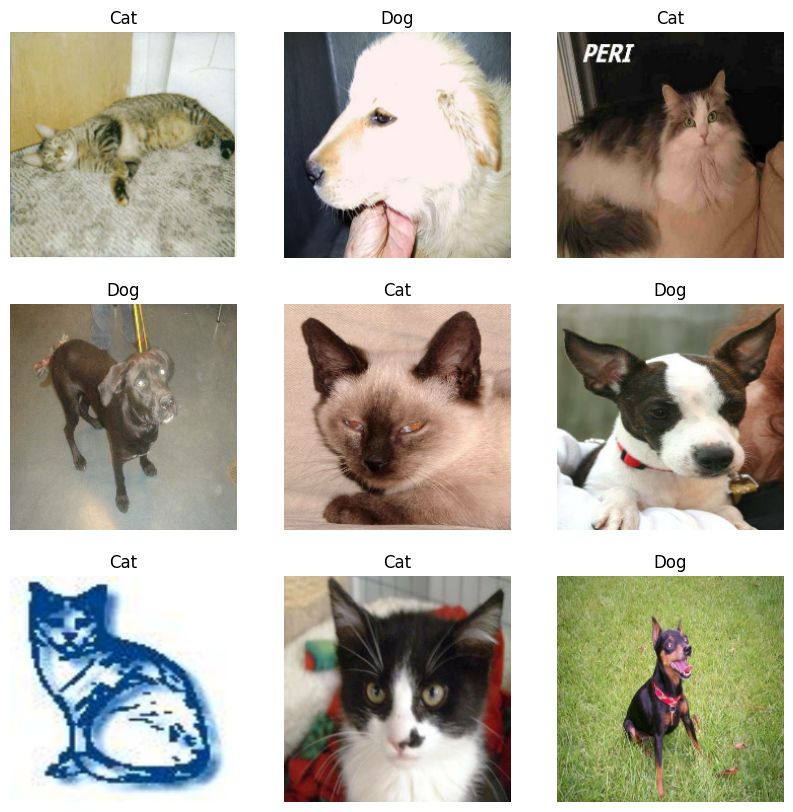

In [12]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title("Dog" if labels[i] else "Cat")
        plt.axis("off")

plt.show()

In [50]:


# 1. Create the augmentation pipeline (No Rescaling here)
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.20),
    layers.RandomZoom(0.20),
    layers.RandomContrast(0.2),
    layers.Rescaling(1./255)
])

In [ ]:


model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization()) # Speeds up learning
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)))

model.add(BatchNormalization()) 
model.add(Dropout(0.6))       

model.add(Dense(1, activation='sigmoid'))



In [52]:
from tensorflow.keras.optimizers import Adam

# --- Compile the Model ---
custom_optimizer = Adam(learning_rate=0.0005)
model.compile(
    optimizer=custom_optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# You can use model.summary() to see a printout of all the layers you just added!
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [53]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [54]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=11,
    callbacks=[early_stop]
)

Epoch 1/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 87ms/step - accuracy: 0.6490 - loss: 1.3169 - val_accuracy: 0.7158 - val_loss: 1.0214
Epoch 2/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 90ms/step - accuracy: 0.7214 - loss: 0.9642 - val_accuracy: 0.7834 - val_loss: 0.7459
Epoch 3/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.8130 - loss: 0.6863 - val_accuracy: 0.6908 - val_loss: 1.0272
Epoch 4/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.8434 - loss: 0.5903 - val_accuracy: 0.8324 - val_loss: 0.6283
Epoch 5/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.8716 - loss: 0.5671 - val_accuracy: 0.8518 - val_loss: 0.6240
Epoch 6/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.8966 - loss: 0.5377 - val_accuracy: 0.8404 - val_loss: 0.6845
Epoch 7/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.9179 - loss: 0.5082 - val_accuracy: 0.8882 - val_loss: 0.5872
Epoch 8/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.9296 - loss: 0.4874 - 

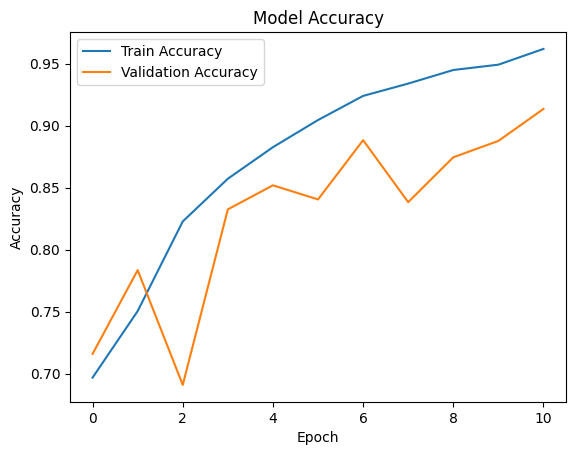

In [55]:
plt.plot(history.history['accuracy'],label="Train Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

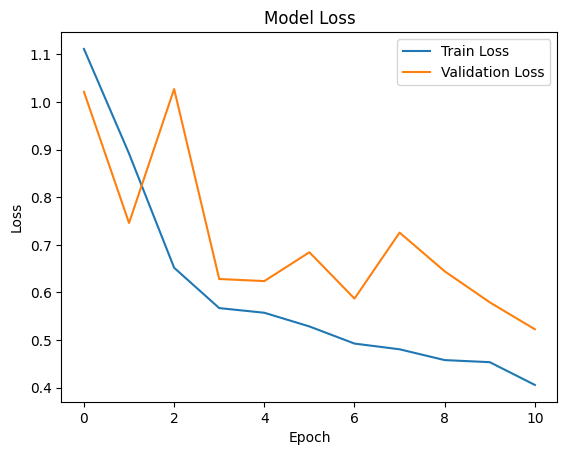

In [56]:
plt.plot(history.history['loss'],label="Train Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [57]:
for i in range(len(history.history['accuracy'])):
    print(f"Epoch {i+1}")
    print("Train Accuracy:", history.history['accuracy'][i])
    print("Validation Accuracy:", history.history['val_accuracy'][i])
    print("Train Loss:", history.history['loss'][i])
    print("Validation Loss:", history.history['val_loss'][i])
    print("----------------------------")

Epoch 1
Train Accuracy: 0.6966999769210815
Validation Accuracy: 0.7157999873161316
Train Loss: 1.111405849456787
Validation Loss: 1.021376609802246
----------------------------
Epoch 2
Train Accuracy: 0.7503499984741211
Validation Accuracy: 0.7833999991416931
Train Loss: 0.8917037844657898
Validation Loss: 0.7458999156951904
----------------------------
Epoch 3
Train Accuracy: 0.8226500153541565
Validation Accuracy: 0.6908000111579895
Train Loss: 0.6519392132759094
Validation Loss: 1.0271767377853394
----------------------------
Epoch 4
Train Accuracy: 0.8571000099182129
Validation Accuracy: 0.8324000239372253
Train Loss: 0.5672539472579956
Validation Loss: 0.6283403038978577
----------------------------
Epoch 5
Train Accuracy: 0.8825500011444092
Validation Accuracy: 0.8518000245094299
Train Loss: 0.5574669241905212
Validation Loss: 0.6239692568778992
----------------------------
Epoch 6
Train Accuracy: 0.904449999332428
Validation Accuracy: 0.840399980545044
Train Loss: 0.528726339340

In [58]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

Final Training Accuracy: 0.9617999792098999
Final Validation Accuracy: 0.9133999943733215
Final Training Loss: 0.4059505760669708
Final Validation Loss: 0.5228114128112793
